Clustering with QAOA with only numpy and scipy

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import networkx as nx
from numba import njit

Construct a graph for community detecting using networkx

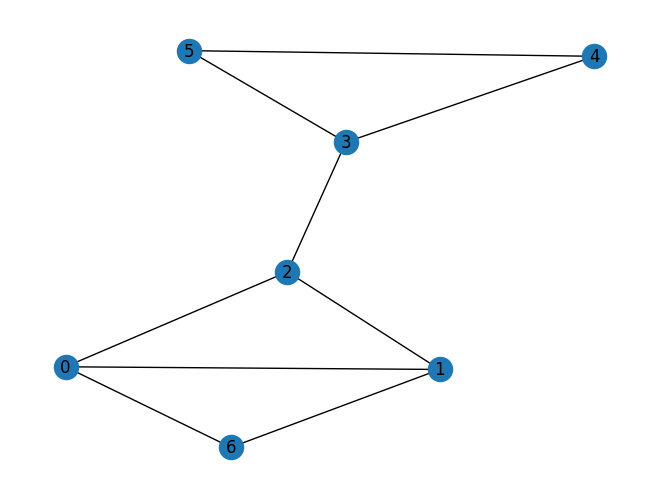

In [6]:
def add_edges(graph: nx.Graph, edges: list):
    for edge in edges:
        graph.add_edge(edge[0], edge[1])

network_graph = nx.Graph()
edges = [(0, 1), (0, 6), (0, 2), (1, 2), (1, 6), (2, 3), (3, 4), (3, 5), (4, 5)]

add_edges(network_graph, edges)
nodelist = sorted(network_graph.nodes())
A = np.array(nx.adjacency_matrix(network_graph, nodelist=nodelist).todense())

nx.draw(network_graph, with_labels=True)
plt.show()

Collect basic information about the graph and define the pauli matrices for Hamiltonian creation

In [7]:
N_QUBITS = len(network_graph.nodes)
DIM = 2 ** N_QUBITS

# Pauli matrices
I2 = np.eye(2, dtype=complex)
Zp = np.array([[1, 0], [0, -1]], dtype=complex)

Construct the function for collection $J_{ij}$ and the constant for the k=2 clustering Ising Hamiltoian $H=\sum_{ij} J_{ij} s_i s_j$. The modularity is given by: $Q=\frac{1}{2m} \sum_{ij} (A_{ij} - \frac{k_i k_j}{2m}) \delta(s_i, s_j)$. With $m=\frac{1}{2}\sum_{ij}A_{ij}$, $k_i = \sum_j A_{ij}$, $A$ is the intercation matrix and $\delta$ is the kronecrerk delta ensuring that we only count nodes beloing to the same clusters. We transform this into the Ising Hamiltoian and utilize a two cluster set up ($k=2$), such that we can diregard the use of super nodes (node expansions) and only use $n$ qubits instead of $k*n$ qubits. The resulting Hamltoian is thereby: $H = \frac{1}{2m} \sum_{ij} (A_{ij} - \frac{k_i k_j}{2m}) \frac{s_i s_j + 1}{2}$, which only consist of a constant and a interaction part. 

In [8]:
def ising_hamiltonian_k2_modularity(A: np.array, alpha: float) -> np.array:
    """
    Get the Ising Hamiltonian matrix J and constant shift for the k=2 
    modularity problem (special "easy" case).
    """
    num_nodes = len(A)
    m = np.sum(A) / 2
    k = A.sum(axis=1)                          
    B = (A - alpha * np.outer(k, k) / (2 * m)) / (2 * m)
    J = np.zeros((num_nodes, num_nodes))
    const = 0.0

    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            J[i, j] += B[i, j]
        const += B[i, i]

    return J, const / 2

We test that this Hamiltoian gives the modularity that we aim for by comparing with the original modularity exparession and the networkx modularity calculation: 

In [10]:
from itertools import product

def modularity_calc(A: np.array, alpha: float, x: np.array) -> float: 
    """
    Calculate the modularity of a given partition x for the adjacency matrix A and resolution parameter alpha.
    """
    num_nodes = len(A)
    m = np.sum(A) / 2

    k = np.zeros(num_nodes)
    for i in range(num_nodes):
        k[i] = np.sum(A[i])

    modularity = 0.0
    for i in range(num_nodes):
        for j in range(num_nodes):
            if x[i] == x[j]:
                modularity += A[i, j] - alpha*(k[i] * k[j]) / (2 * m)
            
    return modularity / (2 * m)

H, const = ising_hamiltonian_k2_modularity(A, alpha=1.0)

print("2-cluster modularity testing for the Ising Hamiltonian: \n")
print("-----------------------------\n")

for x in product(range(2), repeat=N_QUBITS - 1):
    x_full = np.array([0] + list(x), dtype=int)

    z_full = np.array([2*x_i - 1 for x_i in x_full])

    obj_val = modularity_calc(A, alpha=1.0, x=x_full)
    networkx_modularity = nx.algorithms.community.quality.modularity(network_graph, [np.where(x_full == 0)[0].tolist(), np.where(x_full == 1)[0].tolist()])
    H_modularity = z_full @ H @ z_full + const  

    print(f"State: {x_full}  Mod: {obj_val:.4f}     Netx: {networkx_modularity:.4f}    H: {H_modularity:.4f}")

    # Check if all the modularity calculations match
    assert np.isclose(obj_val, networkx_modularity), f"Modularity mismatch for state {x_full}"
    assert np.isclose(obj_val, H_modularity), f"Hamiltonian modularity mismatch for state {x_full}"

2-cluster modularity testing for the Ising Hamiltonian: 

-----------------------------

State: [0 0 0 0 0 0 0]  Mod: 0.0000     Netx: 0.0000    H: 0.0000
State: [0 0 0 0 0 0 1]  Mod: -0.0247     Netx: -0.0247    H: -0.0247
State: [0 0 0 0 0 1 0]  Mod: -0.0247     Netx: -0.0247    H: -0.0247
State: [0 0 0 0 0 1 1]  Mod: -0.0988     Netx: -0.0988    H: -0.0988
State: [0 0 0 0 1 0 0]  Mod: -0.0247     Netx: -0.0247    H: -0.0247
State: [0 0 0 0 1 0 1]  Mod: -0.0988     Netx: -0.0988    H: -0.0988
State: [0 0 0 0 1 1 0]  Mod: 0.1235     Netx: 0.1235    H: 0.1235
State: [0 0 0 0 1 1 1]  Mod: 0.0000     Netx: 0.0000    H: -0.0000
State: [0 0 0 1 0 0 0]  Mod: -0.0556     Netx: -0.0556    H: -0.0556
State: [0 0 0 1 0 0 1]  Mod: -0.1543     Netx: -0.1543    H: -0.1543
State: [0 0 0 1 0 1 0]  Mod: 0.0679     Netx: 0.0679    H: 0.0679
State: [0 0 0 1 0 1 1]  Mod: -0.0802     Netx: -0.0802    H: -0.0802
State: [0 0 0 1 1 0 0]  Mod: 0.0679     Netx: 0.0679    H: 0.0679
State: [0 0 0 1 1 0 1]  Mod:

We know aim to construct the full cost Hamiltoian using the Pauli matrices. 

In [11]:
def kron_op(op: np.ndarray, qubit: int, n_qubits: int) -> np.ndarray:
    """
    Embed single-qubit op on 'qubit' in n-qubit space.
    """
    ops = [I2] * n_qubits
    ops[n_qubits - 1 - qubit] = op   # qubit 0 is the rightmost tensor factor
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def kron_two(op_i: np.ndarray, qi: int, op_j: np.ndarray, qj: int, n_qubits: int) -> np.ndarray:
    """
    Embed two single-qubit operators on different qubits.
    """
    ops = [I2] * n_qubits
    ops[n_qubits - 1 - qi] = op_i
    ops[n_qubits - 1 - qj] = op_j
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def pauli_z_hamiltonian_k2_modularity(A: np.array, alpha: float) -> np.array:
    """
    The full 2^n x 2^n Hamiltonian matrix for the k=2 modularity problem, expressed in the computational basis.
    This is a sum of ZZ terms with coefficients from the Ising Hamiltonian, plus a constant shift.
    """
    num_nodes = len(A)
    DIM = 2 ** num_nodes
    H_C = np.zeros((DIM, DIM), dtype=complex)
    J, const = ising_hamiltonian_k2_modularity(A, alpha)

    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            ZZ = kron_two(Zp, i, Zp, j, num_nodes)
            H_C += J[i, j] * ZZ

    H_C += const * np.eye(DIM, dtype=complex)
    return H_C

We test the cost Hamiltoian for modularity calculaiton to ensure it is correct. 

In [18]:
def bitstring_energy(H_C: np.ndarray, x: np.array) -> float:
    """
    Get energy of a computational basis state from the Pauli-Z Hamiltonian.
    x: binary array of length n, e.g. [0, 1, 0, 1]
    """
    n = len(x)
    # Encode bitstring to matrix index: qubit 0 = most significant bit
    idx = sum(int(x[i]) * (2 ** (n - 1 - i)) for i in range(n))
    return H_C[idx, idx].real

H_C = pauli_z_hamiltonian_k2_modularity(A, alpha=1.0)
cost_diag = np.diag(H_C).real


print("2-cluster modularity testing for the Pauli Hamiltonian: \n")
print("-----------------------------\n")

for x in product(range(2), repeat=N_QUBITS - 1):
    x_full = np.array([0] + list(x), dtype=int)

    z_full = np.array([2*x_i - 1 for x_i in x_full])

    networkx_modularity = nx.algorithms.community.quality.modularity(network_graph, [np.where(x_full == 0)[0].tolist(), np.where(x_full == 1)[0].tolist()])
    H_org = z_full @ H @ z_full + const
    H_modularity = bitstring_energy(H_C, x_full)  # Get energy from the Pauli-Z Hamiltonian

    print(f"State: {x_full}  Netx: {networkx_modularity:.4f}    H_org: {H_org:.4f}    H: {H_modularity:.4f}")

    # Check if all the modularity calculations match
    # assert np.isclose(networkx_modularity, H_modularity), f"Hamiltonian modularity mismatch for state {x_full}"


2-cluster modularity testing for the Pauli Hamiltonian: 

-----------------------------

State: [0 0 0 0 0 0 0]  Netx: 0.0000    H_org: 0.0000    H: 0.0000
State: [0 0 0 0 0 0 1]  Netx: -0.0247    H_org: -0.0247    H: -0.0556
State: [0 0 0 0 0 1 0]  Netx: -0.0247    H_org: -0.0247    H: -0.0556
State: [0 0 0 0 0 1 1]  Netx: -0.0988    H_org: -0.0988    H: 0.0000
State: [0 0 0 0 1 0 0]  Netx: -0.0247    H_org: -0.0247    H: -0.0556
State: [0 0 0 0 1 0 1]  Netx: -0.0988    H_org: -0.0988    H: 0.0000
State: [0 0 0 0 1 1 0]  Netx: 0.1235    H_org: 0.1235    H: 0.0000
State: [0 0 0 0 1 1 1]  Netx: 0.0000    H_org: -0.0000    H: 0.1667
State: [0 0 0 1 0 0 0]  Netx: -0.0556    H_org: -0.0556    H: -0.0556
State: [0 0 0 1 0 0 1]  Netx: -0.1543    H_org: -0.1543    H: -0.2222
State: [0 0 0 1 0 1 0]  Netx: 0.0679    H_org: 0.0679    H: -0.2222
State: [0 0 0 1 0 1 1]  Netx: -0.0802    H_org: -0.0802    H: -0.2778
State: [0 0 0 1 1 0 0]  Netx: 0.0679    H_org: 0.0679    H: 0.0000
State: [0 0 0 1 

In [26]:
N_QUBITS = len(network_graph.nodes)
DIM = 2 ** N_QUBITS

# Pauli matrices
I = np.array([[1, 0], [0, 1]])
Z = np.array([[1, 0], [0, -1]])
X = np.array([[0, 1], [1, 0]])
CX = np.array([[1, 0, 0, 0],
               [0, 1, 0, 0],
               [0, 0, 0, 1],
               [0, 0, 1, 0]])

def single_gate(gate: np.ndarray, qi: int, n_qubits: int) -> np.ndarray:
    """Embed a single-qubit gate on qubit qi in an n-qubit system."""
    ops = [I] * n_qubits
    ops[n_qubits - 1 - qi] = gate
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def cnot(qi: int, qj: int, n_qubits: int) -> np.ndarray:
    """Embed CNOT with control qi and target qj in an n-qubit system."""
    dim = 2**n_qubits
    result = np.zeros((dim, dim), dtype=complex)
    for state in range(dim):
        # Check control qubit qi (in big-endian convention)
        control_bit = (state >> qi) & 1
        if control_bit == 0:
            result[state, state] = 1.0      # control=0: do nothing
        else:
            # Flip target qubit qj
            flipped = state ^ (1 << qj)
            result[flipped, state] = 1.0    # control=1: flip target
    return result

def rzz(theta: float, qi: int, qj: int, n_qubits: int) -> np.ndarray:
    """
    R_ZZ(theta) = CNOT_ij . (I ⊗ Rz(theta)) . CNOT_ij
    Applied on qubits qi (control) and qj (target).
    """
    Rz = np.array([[np.exp(-1j * theta / 2), 0],
                   [0,  np.exp( 1j * theta / 2)]], dtype=complex)

    CNOT = cnot(qi, qj, n_qubits)
    RZ   = single_gate(Rz, qj, n_qubits)   # Rz acts on target qubit

    return CNOT @ RZ @ CNOT


def rx(theta: float, qubit: int, n_qubits: int) -> np.ndarray:
    """Embed single-qubit x-rotation on 'qubit' in n-qubit space."""
    Rx = np.array([[np.cos(theta / 2), -1j*np.sin(theta / 2)],
                   [-1j*np.sin(theta / 2), np.cos(theta / 2)]], dtype=complex)

    return single_gate(Rx, qubit, n_qubits)

In [27]:
# -----------------------------------------------------------------------------
# Functions for testing the correctness of the above implementations
# -----------------------------------------------------------------------------
def kron_two(op_i: np.ndarray, qi: int, op_j: np.ndarray, qj: int, n_qubits: int) -> np.ndarray:
    """Embed two single-qubit operators on different qubits."""
    ops = [I] * n_qubits
    ops[n_qubits - 1 - qi] = op_i
    ops[n_qubits - 1 - qj] = op_j
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def rzz_direct(theta: float, qi: int, qj: int, n_qubits: int) -> np.ndarray:
    """Direct matrix exponential e^{-i theta/2 Z_i Z_j} for comparison."""
    ZZ = kron_two(Z, qi, Z, qj, n_qubits)
    return expm(-1j * theta / 2 * ZZ)

def rx_direct(theta: float, qi: int, n_qubits: int) -> np.ndarray:
    """Direct matrix exponential e^{-i theta/2 X_i} for comparison."""
    X_op = single_gate(X, qi, n_qubits)
    return expm(-1j * theta / 2 * X_op)

# Test the rzz implementation against the direct matrix exponential
from scipy.linalg import expm
theta = 0.7
n = 3
diff = np.max(np.abs(rzz(theta, 0, 1, n) - rzz_direct(theta, 0, 1, n)))
print(f"Max difference: {diff:.2e}")  # Should be ~1e-16

# Test the rx implementation against a direct matrix exponential
theta = 0.7
n = 3
diff = np.max(np.abs(rx(theta, 0, n) - rx_direct(theta, 0, n)))
print(f"Max difference: {diff:.2e}")  # Should be ~1e-16

Max difference: 0.00e+00
Max difference: 5.55e-17


In [28]:
# Hamiltonian plotting: 
def fmt(x: complex) -> str:
    """Format complex number: show only non-zero parts, 2 decimals."""
    r, i = round(x.real, 2), round(x.imag, 2)
    if r == 0 and i == 0:
        return "0.00"
    elif i == 0:
        return f"{r:.2f}"
    elif r == 0:
        return f"{i:.2f}j"
    else:
        return f"{r:.2f}+{i:.2f}j"

def print_matrix(M: np.ndarray, label: str, size: int = 4):
    print(f"{label}:")
    for row in M[:size, :size]:
        print("  " + "  ".join(fmt(x) for x in row))
    print()

In [ ]:
# ------------------------------------------------------------------------------
# The main QAOA functions to build the cost and mixer unitaries, construct the state, and compute expectation values.
# ------------------------------------------------------------------------------

def build_cost_unitary(pauli_list: list, N_QUBITS: int, gamma: float) -> np.ndarray:
    """U_c(gamma) = product of RZZ gates for all edges."""
    U = np.eye(2**N_QUBITS, dtype=complex)
    for op, qubits, coeff in pauli_list:
        if op == "ZZ":
            U = rzz(gamma * coeff, qubits[0], qubits[1], N_QUBITS) @ U
    return U

def build_mixer_unitary(N_QUBITS: int, beta: float) -> np.ndarray:
    """U_m(beta) = product of RX gates on all qubits."""
    U = np.eye(2**N_QUBITS, dtype=complex)
    for i in range(N_QUBITS):
        U = rx(beta, i, N_QUBITS) @ U
    return U

def qaoa_engine(pauli_list: list, N_QUBITS: int, state: np.ndarray, gamma: float, beta: float) -> np.ndarray:
    """
    Preform one layer of QAOA: |psi> = U_m(beta) U_c(gamma) |+>^n
    """
    U_c = build_cost_unitary(pauli_list, N_QUBITS, gamma)
    U_m = build_mixer_unitary(N_QUBITS, beta)
    state = U_m @ U_c @ state  # apply cost first, then mixer
    return state

# Build the bare cost Hamiltonian (not multiplied by gamma)
def build_cost_hamiltonian(pauli_list: list, N_QUBITS: int) -> np.ndarray:
    H = np.zeros((2**N_QUBITS, 2**N_QUBITS), dtype=complex)
    for op, qubits, coeff in pauli_list:
        if op == "ZZ":
            H += coeff * kron_two(Z, qubits[0], Z, qubits[1], N_QUBITS)
    return H

p = 1
gammas = np.array([1.0])
betas  = np.array([1.0])

pauli_list = build_k2_cluster(network_graph, alpha=1.0)
H_c = build_cost_hamiltonian(pauli_list, N_QUBITS)

print_matrix(H_c[:4, :4], "H_c (first 4x4 block)")

H_c (first 4x4 block):
  -0.50  0.00  0.00  0.00
  0.00  -0.33  0.00  0.00
  0.00  0.00  -0.33  0.00
  0.00  0.00  0.00  -0.19



In [32]:
# ------------------------------------------------------------------------------
# Expected value QAOA sampling 
# ------------------------------------------------------------------------------
def qaoa_run(p: int, gammas: np.ndarray, betas: np.ndarray, pauli_list: list, N_QUBITS: int):
    # Initial state: uniform superposition |+>^n
    dim = 2**N_QUBITS
    plus = np.ones(dim, dtype=complex) / np.sqrt(dim)
    state = plus.copy()
    
    for k in range(p):
        U_c = build_cost_unitary(pauli_list, N_QUBITS, gammas[k])
        U_m = build_mixer_unitary(N_QUBITS, betas[k])
        state = U_m @ U_c @ state  # apply cost first, then mixer
    
    return state

def expectation_value(p: int, params: np.ndarray, pauli_list: list, N_QUBITS: int) -> float:
    """<psi|H_c|psi>"""
    gammas = params[:p]
    betas = params[p:]
    state = qaoa_run(p, gammas, betas, pauli_list, N_QUBITS)
    return np.real(state.conj() @ H_c @ state)

# Optimise for p=1,5,10 using COBYLA with random restarts
results = {}
print('Optimising QAOA parameters:')
print()

for p in [1, 5, 10]:
    best_val = np.inf
    best_res = None
    n_restarts = 20 if p == 1 else 30

    for _ in range(n_restarts):
        g0 = np.random.uniform(0, np.pi,    p)
        b0 = np.random.uniform(0, np.pi/2,  p)
        x0 = np.concatenate([g0, b0])
        res = minimize(lambda params: -expectation_value(p, params, pauli_list, N_QUBITS), x0,
                       method='COBYLA', options={'maxiter': 2000, 'rhobeg': 0.5})
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    energy     = -best_val
    psi_opt    = qaoa_run(p, best_res.x[:p], best_res.x[p:], pauli_list, N_QUBITS)
    probs_opt  = np.abs(psi_opt) ** 2

    results[p] = {'params': best_res.x, 'energy': energy,
                  'probs': probs_opt, 'state': psi_opt}

    print(f'  p={p}: E={energy:.4f}  params={best_res.x}  state={psi_opt[:4]}')



Optimising QAOA parameters:



KeyboardInterrupt: 

Brute-force optimal k-cluster modularity Q c calculation: 

-----------------------------


Optimal 2-cluster partition (Q = 0.3166)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (6 nodes): [4, 5, 6, 7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

Optimal 3-cluster partition (Q = 0.3512)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (3 nodes): [4, 5, 6]
  Cluster 2 (3 nodes): [7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 1, 1, 2, 2, 2]

Optimal 4-cluster partition (Q = 0.2907)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (1 nodes): [4]
  Cluster 2 (1 nodes): [5]
  Cluster 3 (4 nodes): [6, 7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 2, 3, 3, 3, 3]

Optimal 5-cluster partition (Q = 0.2422)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (1 nodes): [4]
  Cluster 2 (1 nodes): [5]
  Cluster 3 (1 nodes): [6]
  Cluster 4 (3 nodes): [7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 2, 3, 4, 4, 4]


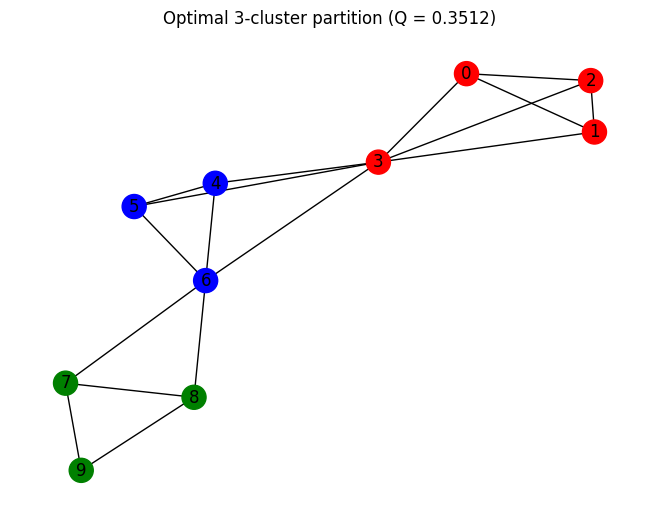

In [ ]:
from itertools import product

print("Brute-force optimal k-cluster modularity Q calculation: \n")
print("-----------------------------\n")

for n_clusters in [2, 3, 4, 5]:
    best_val = -np.inf
    best_config = None

    # Enumerate all n_clusters^N_QUBITS labellings
    # To avoid counting permutations of labels as different solutions,
    # we fix node 0 to cluster 0 (breaks label symmetry)
    for z in product(range(n_clusters), repeat=N_QUBITS - 1):
        z_full = np.array([0] + list(z), dtype=int)

        # Skip configurations that don't use all n_clusters labels
        # (those are really k<n_clusters partitions)
        if len(np.unique(z_full)) < n_clusters:
            continue

        obj_val = modularity_calc(A, alpha=1.0, z=z_full)
        if obj_val > best_val:
            best_val = obj_val
            best_config = z_full.copy()

    # Summary
    print(f"\nOptimal {n_clusters}-cluster partition (Q = {best_val:.4f})")
    for c in range(n_clusters):
        nodes = np.where(best_config == c)[0].tolist()
        print(f"  Cluster {c} ({len(nodes)} nodes): {nodes}")
    print(f"  Labelling: {best_config.tolist()}")

    if n_clusters == 3:
        best_3_config = best_config.copy()
        best_3_val = best_val

# Plot
cmap = ['red', 'blue', 'green', 'orange', 'purple']
color_map = [cmap[best_3_config[i]] for i in range(N_QUBITS)]
plt.figure()
nx.draw(network_graph, with_labels=True, node_color=color_map)
plt.title(
    f"Optimal 3-cluster partition (Q = {best_3_val:.4f})"
)
plt.show()

In [ ]:
# ------------------------------------------------------------------------------
# Create the pauli list for the clustering problem
# ------------------------------------------------------------------------------
def build_k2_cluster(graph: nx.Graph, alpha: float) -> list:
    """Build the Pauli operator for the clustering problem."""
    num_nodes = len(graph.nodes)

    # Calculate the sum over all edges
    m = graph.size(weight='weight')
    
    # Calculate edge degree for each node
    k = np.zeros(num_nodes)
    for i in range(num_nodes):
        k[i] = graph.degree(i, weight='weight')

    pauli_list = []
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                # Add the modularity term
                edge_data = graph.get_edge_data(i, j)
                weight = edge_data.get('weight', 1) if edge_data else 0
                
                Q = weight - alpha*(k[i] * k[j]) / (2 * m)
                pauli_list.append(("ZZ", [i, j], Q))

    return pauli_list

# ------------------------------------------------------------------------------
# Precompute the diagonal of the cost Hamiltonian for efficient expectation value calculation
# ------------------------------------------------------------------------------
def build_cost_diagonal(pauli_list: list, N_QUBITS: int) -> np.ndarray:
    """Diagonal of H_c in the computational basis."""
    dim = 2**N_QUBITS
    diag = np.zeros(dim, dtype=float)
    for op, (qi, qj), coeff in pauli_list:
        if op == "ZZ":
            for state in range(dim):
                zi = 1 - 2*((state >> qi) & 1)  # +1 or -1
                zj = 1 - 2*((state >> qj) & 1)
                diag[state] += coeff * zi * zj
    return diag

# Create the pauli list and precompute the cost diagonal
pauli_list = build_k2_cluster(network_graph, alpha=1.0)
cost_diag = build_cost_diagonal(pauli_list, N_QUBITS)